Milestone 1: Data Understanding & Exploration
- Load the diabetes dataset using scikit-learn and display the first five rows
- Perform descriptive statistics (mean, median, min, max) and summarize class balance
- Visualize the distributions of at least two features using histograms or box plots

In [7]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df_diabetes = diabetes.frame
print("\nDiabetes Dataset:")
print(df_diabetes.head())



Diabetes Dataset:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  



Descriptive Statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761

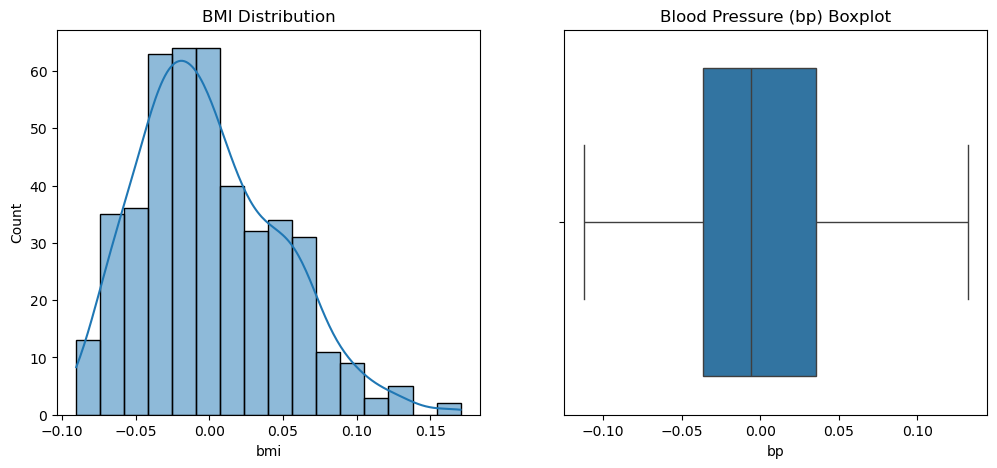

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df_diabetes.describe())

# Check for missing values
print("\nMissing Values:")
print(df_diabetes.isna().sum())

# Feature distribution plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_diabetes['bmi'], kde=True)
plt.title("BMI Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df_diabetes['bp'])
plt.title("Blood Pressure (bp) Boxplot")

plt.show()


Milestone 2: Data Preparation & Preprocessing
- Handle any missing values, duplicates, or outliers in the dataset
- Apply feature scaling/normalization
- Encode categorical variables (if present) with a suitable technique
- Perform basic correlation analysis and point out highly correlated features


Class Balance:
target_binary
1    221
0    221
Name: count, dtype: int64


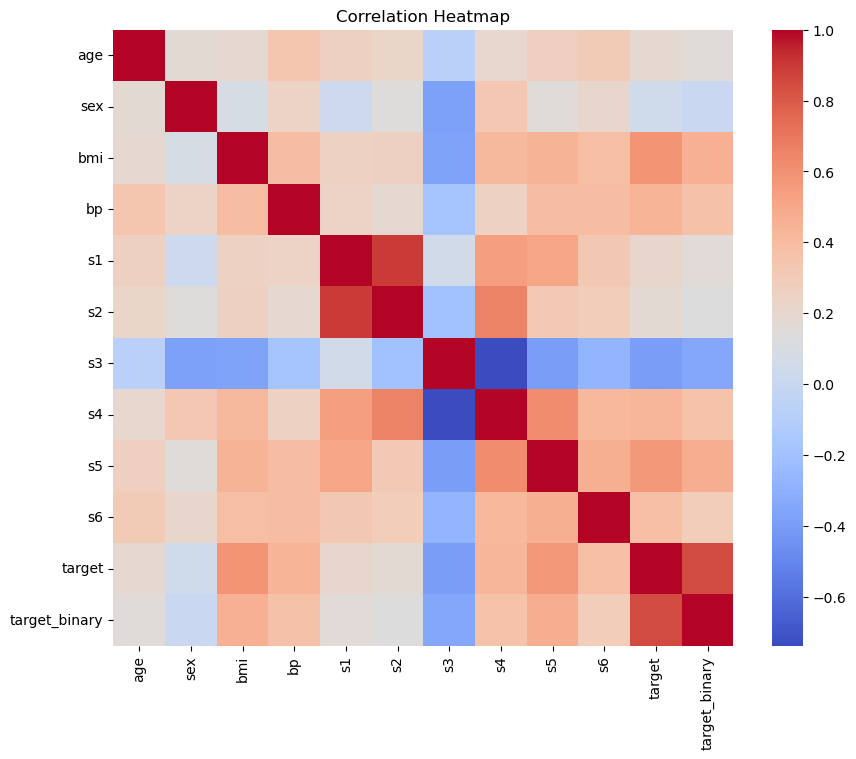

In [8]:
from sklearn.preprocessing import StandardScaler

# Convert regression target into binary classes
df_diabetes['target_binary'] = (df_diabetes['target'] > df_diabetes['target'].median()).astype(int)

print("\nClass Balance:")
print(df_diabetes['target_binary'].value_counts())

# Handle duplicates (unlikely)
df_diabetes = df_diabetes.drop_duplicates()

# No missing values in this dataset

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(df_diabetes.drop(['target', 'target_binary'], axis=1))
y = df_diabetes['target_binary']

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_diabetes.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


Milestone 3: Model Selection & Training
- Split the dataset into training and test sets with a suitable ratio
- Choose and train at least two machine learning models (e.g., logistic regression, random forest)
- Include hyperparameter tuning with cross-validation for one chosen model

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Hyperparameter tuning for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best RF Parameters:", grid.best_params_)


Best RF Parameters: {'max_depth': 8, 'n_estimators': 50}


Milestone 4: Model Evaluation & Interpretation
- Evaluate the trained models with appropriate metrics (accuracy, ROC-AUC, precision, recall)
- Plot and interpret a confusion matrix for the best model


=== Logistic Regression ===
Accuracy: 0.7477477477477478
ROC-AUC: 0.8580327868852459
Precision: 0.72
Recall: 0.72
F1 Score: 0.72

=== Random Forest ===
Accuracy: 0.7747747747747747
ROC-AUC: 0.8360655737704917
Precision: 0.7358490566037735
Recall: 0.78
F1 Score: 0.7572815533980582


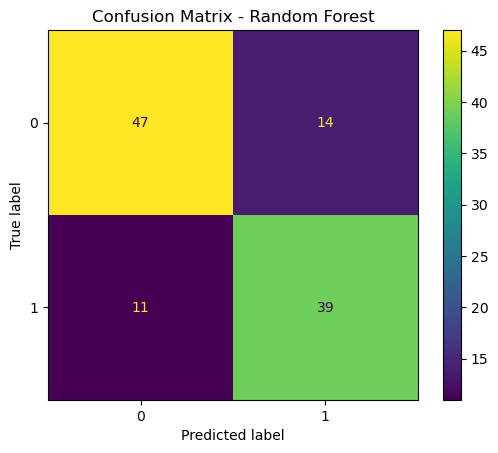

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---- Logistic Regression Evaluation ----
y_pred_log = log_reg.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_log, average='binary')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ---- Random Forest Evaluation ----
y_pred_rf = best_rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]))
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ---- Confusion Matrix for Best Model (Random Forest) ----
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Select best model explicitly
best_model = best_rf


Milestone 5: Deployment & Reporting
- save your final trained model for later use
- load the model and making a new prediction

In [12]:
import joblib

# Save model
joblib.dump(best_model, "final_diabetes_model.pkl")
print("Model saved as final_diabetes_model.pkl")

# Load model
loaded_model = joblib.load("final_diabetes_model.pkl")

# Make a new prediction using first test row
sample = X_test[0].reshape(1, -1)
prediction = loaded_model.predict(sample)
print("Prediction for new sample:", prediction)


Model saved as final_diabetes_model.pkl
Prediction for new sample: [0]
